Titanic Survival Prediction

In [134]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score


In [68]:
df = pd.read_csv("Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [70]:
df.shape

(891, 12)

In [72]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [76]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [78]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [80]:
df.value_counts()

PassengerId  Survived  Pclass  Name                                                  Sex     Age   SibSp  Parch  Ticket    Fare      Cabin  Embarked
2            1         1       Cumings, Mrs. John Bradley (Florence Briggs Thayer)   female  38.0  1      0      PC 17599  71.2833   C85    C           1
572          1         1       Appleton, Mrs. Edward Dale (Charlotte Lamson)         female  53.0  2      0      11769     51.4792   C101   S           1
578          1         1       Silvey, Mrs. William Baird (Alice Munger)             female  39.0  1      0      13507     55.9000   E44    S           1
582          1         1       Thayer, Mrs. John Borland (Marian Longstreth Morris)  female  39.0  1      1      17421     110.8833  C68    C           1
584          0         1       Ross, Mr. John Hugo                                   male    36.0  0      0      13049     40.1250   A10    C           1
                                                                                 

In [82]:
num_columns = df.select_dtypes(include=['number']).columns.tolist()
cat_columns = df.select_dtypes(include = ['object', 'category']).columns.tolist()

In [84]:
num_columns

['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

In [86]:
cat_columns

['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']

In [88]:
df.groupby('Sex')[["Survived"]].mean()

,Survived
Sex,
female,0.742038
male,0.188908


In [90]:
df.groupby('Pclass')[["Survived"]].mean()

,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363


C:\Users\veray\AppData\Local\Temp\ipykernel_42860\2679648191.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Sex', y='Survived', palette='pastel')
C:\Users\veray\AppData\Local\Temp\ipykernel_42860\2679648191.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Pclass', y='Survived', palette='crest')


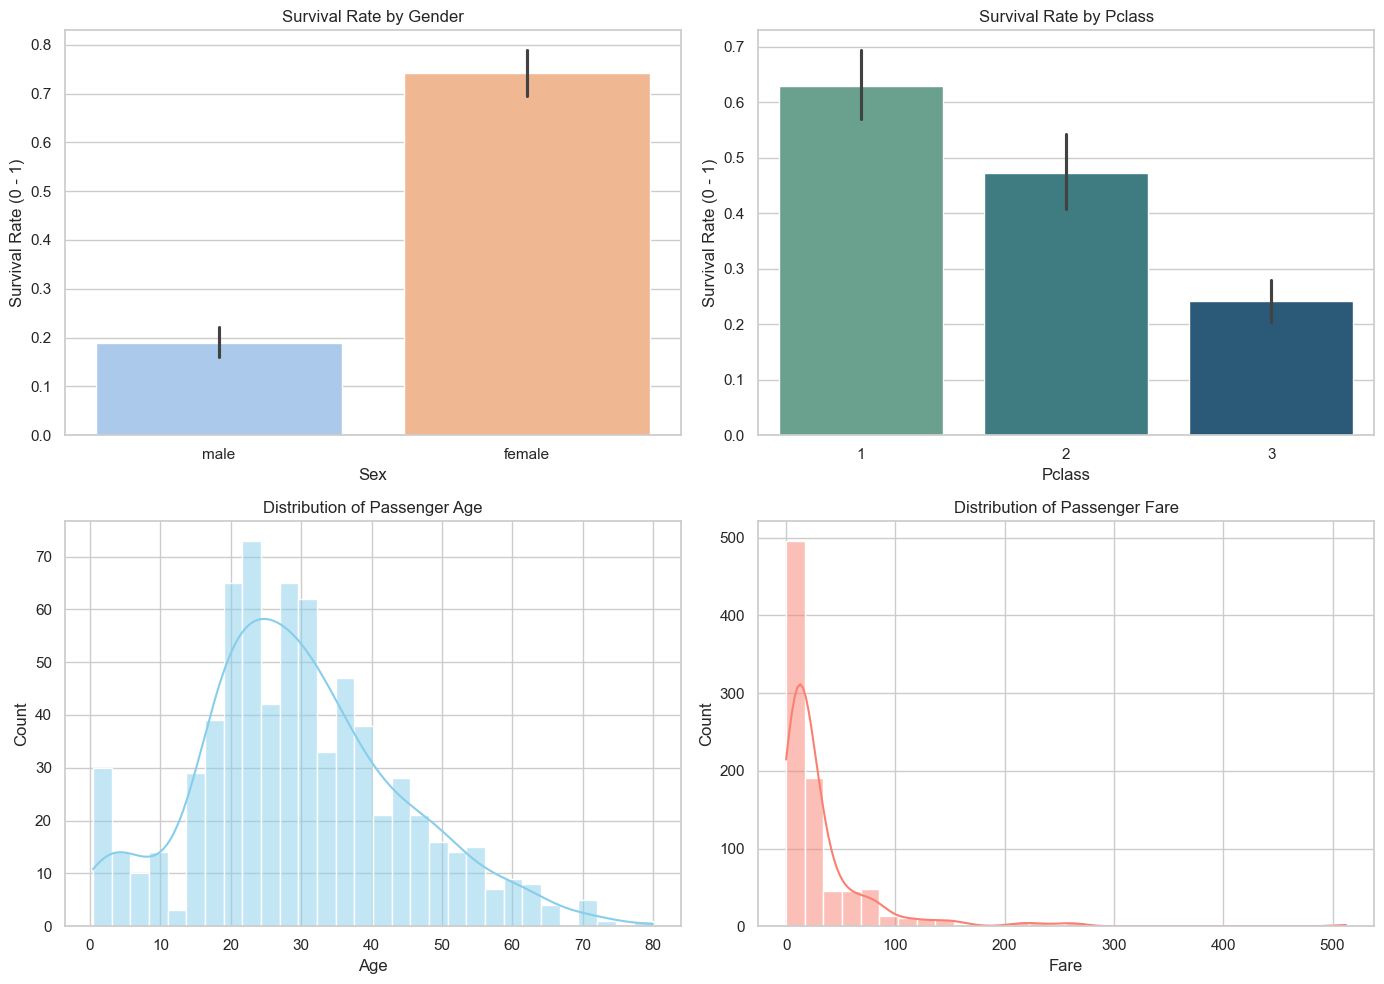

In [93]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14,10))

plt.subplot(2,2,1)
sns.barplot(data=df, x='Sex', y='Survived', palette='pastel')
plt.title("Survival Rate by Gender")
plt.ylabel('Survival Rate (0 - 1)')

plt.subplot(2,2,2)
sns.barplot(data=df, x='Pclass', y='Survived', palette='crest')
plt.title("Survival Rate by Pclass")
plt.ylabel('Survival Rate (0 - 1)')

plt.subplot(2,2,3)
sns.histplot(df['Age'].dropna(), kde=True, bins=30, color='skyblue')
plt.title('Distribution of Passenger Age')
plt.xlabel('Age')

plt.subplot(2,2,4)
sns.histplot(df['Fare'], kde=True, bins=30, color='salmon')
plt.title('Distribution of Passenger Fare')
plt.xlabel('Fare')

plt.tight_layout()
plt.show()

In [94]:
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

C:\Users\veray\AppData\Local\Temp\ipykernel_42860\3744086084.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)


In [95]:
# df["Age"].fillna(df["Age"].mean())

In [96]:
df['Age'] = df.groupby('Pclass')['Age'].transform(lambda x: x.fillna(x.median()))

In [97]:
# df.drop(columns = ["Cabin"], inplace=True)

In [98]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

In [103]:
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

In [107]:
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+).', expand=False)

rare_titles = ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']
df['Title'] = df['Title'].replace(rare_titles, 'Rare')
df['Title'] = df['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})

In [109]:
df['HasCabin'] = df['Cabin'].notna().astype(int)

In [117]:
features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked", "HasCabin"]
X = df[features].copy()
y = df["Survived"]

X = pd.get_dummies(X, columns = ["Sex", "Embarked"], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Testing set size:  {X_test.shape[0]} rows\n")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print(f"=== Model Accuracy: {accuracy * 100:.2f}% ===")

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))

Training set size: 712 rows
Testing set size:  179 rows

=== Model Accuracy: 81.01% ===

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.83      0.86      0.85       110
           1       0.77      0.72      0.75        69

    accuracy                           0.81       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.81      0.81      0.81       179



In [132]:
y.value_counts(normalize=True)

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

In [126]:
y_train.value_counts(normalize=True)

Survived
0    0.616573
1    0.383427
Name: proportion, dtype: float64

In [128]:
y_test.value_counts(normalize=True)

Survived
0    0.614525
1    0.385475
Name: proportion, dtype: float64

In [119]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[95 15]
 [19 50]]


In [136]:
scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print(scores)
print(scores.mean())
print(scores.std())

[0.79888268 0.79213483 0.80898876 0.78089888 0.79775281]
0.7957315924926245
0.009194709701792779


C:\Users\veray\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\veray\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_